# 5000 Metres Analysis

Historical analysis and future projections for the 5000 Metres.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath('../'))

from src.data_cleaner import DataCleaner
from src.analysis_engine import AnalysisEngine
from src.forecaster import TrackForecaster

sns.set_theme(style='whitegrid')

## 1. Data Generation (Synthetic)

In [2]:
start_year = 1980
end_year = 2023
years = list(range(start_year, end_year + 1))
data = []
base_time = 790.0
improvement_rate = 0.5

np.random.seed(42)
for y in years:
    # Annual improvement trend
    year_best = base_time - (y - start_year) * improvement_rate + (np.random.random() * (improvement_rate * 5))
    for _ in range(50):
        data.append({
            'year': y,
            'mark': f'{year_best + np.random.random() * (base_time * 0.05):.2f}',
            'wind': '1.0',
            'athlete': f'Athlete_{np.random.randint(1000)}',
            'date': f'{y}-07-15',
            'event': '5000-metres'
        })

df = pd.DataFrame(data)
df.head()

,year,mark,wind,athlete,date,event
0,1980,828.49,1.0,Athlete_106,1980-07-15,5000-metres
1,1980,821.73,1.0,Athlete_20,1980-07-15,5000-metres
2,1980,797.10,1.0,Athlete_466,1980-07-15,5000-metres
3,1980,794.89,1.0,Athlete_458,1980-07-15,5000-metres
4,1980,825.15,1.0,Athlete_99,1980-07-15,5000-metres


## 2. Analysis

In [3]:
cleaner = DataCleaner()
clean_df = cleaner.clean_scraped_data(df)

engine = AnalysisEngine(clean_df)
stats_df = engine.get_yearly_stats()
stats_df.tail()

,year,best,top_10_avg,median,count
39,2019,775.57,779.222,796.235,50
40,2020,772.30,776.632,790.660,50
41,2021,771.81,774.765,787.745,50
42,2022,771.23,774.023,788.420,50
43,2023,768.88,775.665,790.725,50


## 3. Projection

14:22:33 - cmdstanpy - INFO - Chain [1] start processing


14:22:33 - cmdstanpy - INFO - Chain [1] done processing


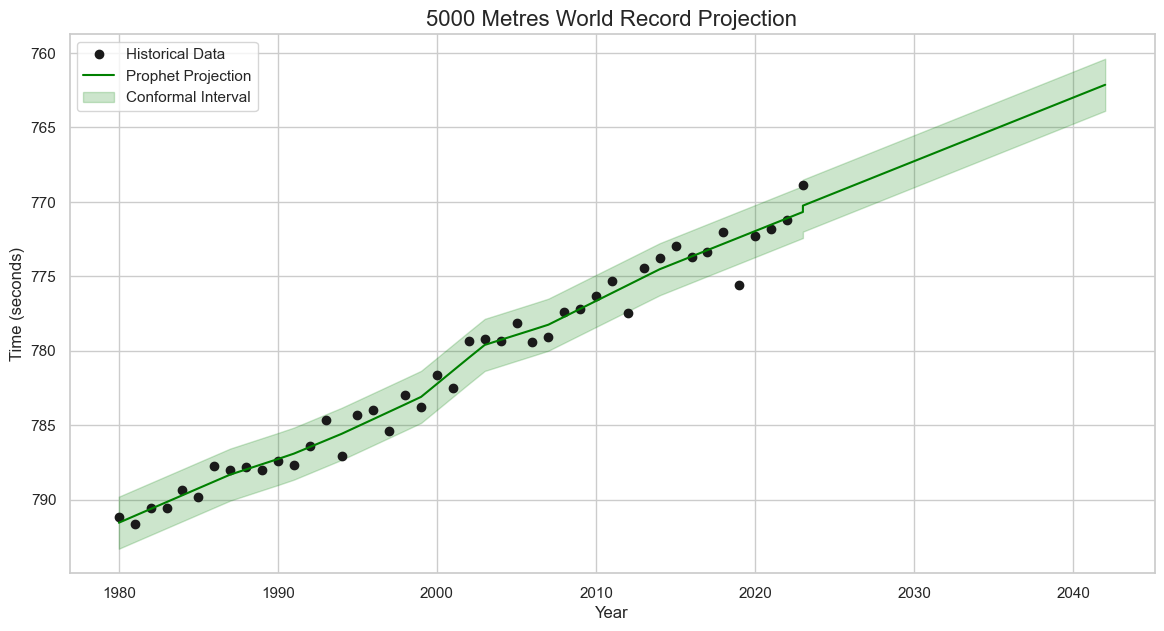

In [4]:
forecaster = TrackForecaster(stats_df)
forecast = forecaster.forecast(periods=20)

plt.figure(figsize=(14, 7))
plt.plot(stats_df['year'], stats_df['best'], 'ko', label='Historical Data')
plt.plot(pd.to_datetime(forecast['ds']).dt.year, forecast['yhat'], color='green', label='Prophet Projection')
plt.fill_between(pd.to_datetime(forecast['ds']).dt.year, forecast['yhat_lower'], forecast['yhat_upper'], color='green', alpha=0.2, label='Conformal Interval')

plt.title(f'5000 Metres World Record Projection', fontsize=16)
plt.ylabel('Time (seconds)')
plt.xlabel('Year')
plt.gca().invert_yaxis()
plt.legend()
plt.show()